# Classification_CNN_cifar10 Optimization Report

Name: Anders Overgaard Lisberg



## Introduction

I've chosen to improve the Classification_CNN_cifar10 notebook from lecture 3. The notebook is a very straightforward implementation of a CNN for image classification on the CIFAR-10 dataset. 

### Goal of optimization

Intially, the model achieves an overall accuracy of 55% with poor performance on "cat" at 24.3% and "dog" at 31.0%. The target for optimzation is the Test Accuracy, aiming to increase the it to at least 70%.

I want to acieve this **without increasing the complexity of the model**. Modifying the architecture by adding layers or changing filter sizes introduces many confounding variables at once. 

The provided `Net()` architecture seems to be a variant of [LeNet](https://d2l.ai/chapter_convolutional-neural-networks/lenet.html), originally designed for black-white images. CIFAR contains colored images, thus, in this assignment, I'll see if it is possible to increase accuracy, or if it requires a deeper network to extract more meaningful features.



## Methodology

Multiple bottlenecks were initially identified in the original notebook, including:

1. **Undertraining**: The original model was trained for 2 epochs, which is likely insufficient for convergence.
2. **Inefficient Batch Size**: A batch size of 4 seems very small, conceptionally leading to noisy gradient updates and inefficient training.
3. **Lack of Regularization**: When training more, regularization might be needed, to improve generalization without adding architectual complexity (like dropout or batch normalization layers). Thus adding data augmentation and L2 regularzation might help combat this.

## Results

### Undertraining

First I'll train the model with early stopping to see how much of the poor performance is due to understraining. The training set is split 85% for training and 15% for validation. Patience is set to 5, meaning that if the validation loss does not improve for 5 consecutive epochs, training will stop. The best model will be saved and loaded after training.

In the below picture, the training and validation loss are plotted. The training loss decreases steadily, while the validation loss starts to increase after around 4 epochs, indicating overfitting. The best model is achieved at epoch 4 with a validation loss. Comparning the model to the test set, the overall accuracy is 58%, which is a slight improvement from the original 55%.
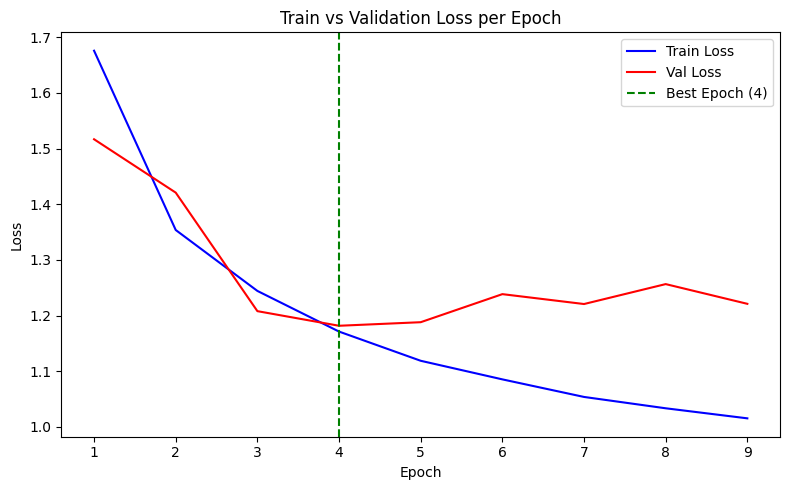

This is not a significant improvement, but it does show that the model is undertrained.

For code, please see code section in the very buttom.

### Batch Size

Next, I'll increase the batch size to 64 and train the model again with early stopping, like before. The training and validation loss are plotted below.
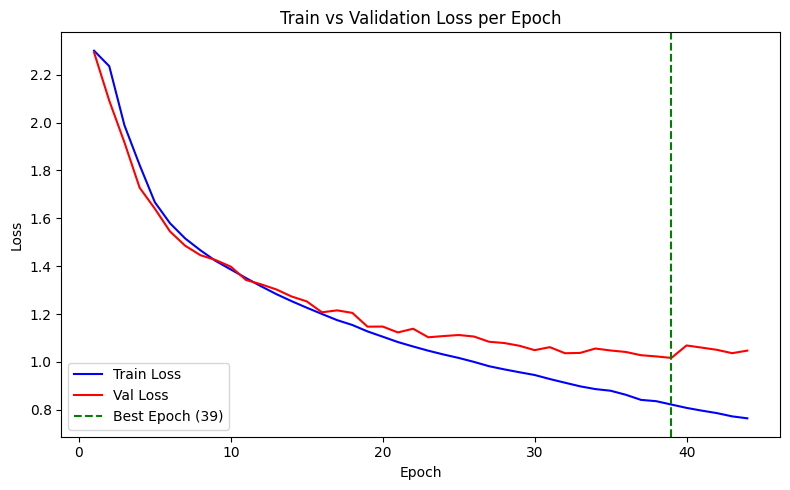

Increasing batch size to 64 has a significant impact on the training process. The model now trains for 44 epochs before early stopping, with best model saved at epoch 39. Despite longer training time, the overall accuracy on the test set is 64%.
However, the wide gap that eventually forms between the training and validation loss hints that the model is simply momorizing the training data over. This suggests that the model might need regularization.

```python
batch_size = 64
```

### Regularization

**Data Augmentation**

To address the overfitting from the previous experiment, I added random horizontal flips and random roations up to 10 degrees. Each version presents

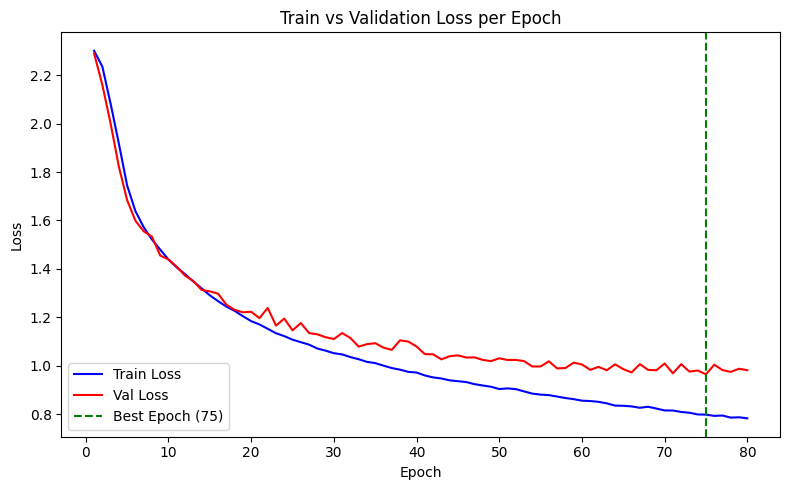

The theory is that the model's ability to memorize the training data is reduced, when adding data augmentation, which closes the gap between train and val loss. But the model's capacity may not be sufficient to fully benefit from the regularization. Overall test accuracy slightly increased to 68%.


```python
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # <-- Added random horizontal flip
    transforms.RandomRotation(10), # <-- Added random rotation up to 10 degrees
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
``` 

**Weight decay / L2 regularization**

I added a weight decay of 1e-4 to the SGD-optimizer to contrain the weights and encourage the model to learn more generalized features. The training and validation loss are plotted below.

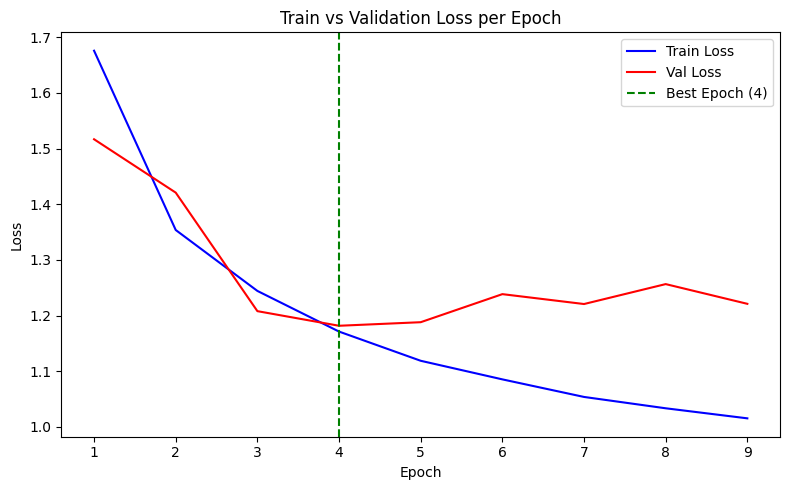
After training with both Data Augmentation and Weight Decay, the overall test accuracy achieved was **67%**.


```python
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
```

## Analysis

Interestingly, the accuracy slightly decreased from the 68% achieved with Data Augmentation alone. Because I strictly adhered to the constraint of not increasing the model's architectural complexity, adding *too much* regularization likely bottlenecked the network. The provided architecture is relatively small. Applying heavy mathematical constraints on top of augmented data caused it to slightly underfit the CIFAR-10 dataset.

| Optimization Step | Key Modifications | Overall Test Accuracy |
| :--- | :--- | :--- |
| **1. Baseline** | 2 Epochs, Batch Size 4 | 55% |
| **2. Early Stopping** | 15% Val Split, Patience 5 | 58% |
| **3. Batch Size** | Increased Batch Size to 64 | 64% |
| **4. Data Augmentation** | RandomHorizontalFlip, RandomRotation(10) | **68%** |
| **5. L2 Regularization** | Added `weight_decay=1e-4` | 67% |


## Conclusion

The Primary objective of this optimzation was to increase the baseline model's test accuracy from 55% to at least 70%, strictly without increasing the model's architectural complexity.

While the optimzations increases 13% in accuracy, peaking at 68%, it did not meet the target of at least 70%.
Upon review, the contraint to avoid changing the mdoel's architecture likely limited the objective from the start. The ``Net()`` is made for simple 28x28 grayscale images like MNIST dataset. Expecting it to capture the more complex dataset, might be optimistic.

## Code

In [ ]:
pre_trained_flag = False # Set to False if you want to train the model

import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # <-- Added random horizontal flip
    transforms.RandomRotation(10), # <-- Added random rotation up to 10 degrees
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 64

full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)

# Split into train and validation sets
train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(testset)}')

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
net.to(device)

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4) # <-- Added L2 regularization with weight decay of 1e-4

if pre_trained_flag:

    !gdown --id 1NW2A_4yJi-ruAFkcM2ZwVu0paAxWoP1L

    PATH = './cifar_net.pth'

    net = Net()
    net.load_state_dict(torch.load(PATH, map_location=torch.device(device)))

if not pre_trained_flag:
    val_losses = []
    train_losses = []

    best_val_loss = float('inf')
    best_epoch = 0
    PATH = './cifar_net.pth'

    for epoch in range(100):

        # --- Training ---
        net.train()
        train_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(trainloader)
        train_losses.append(train_loss)

        # --- Validation ---
        net.eval()
        val_loss = 0.0
        with torch.no_grad():
            for data in valloader:
                images, labels = data[0].to(device), data[1].to(device)
                outputs = net(images)
                val_loss += criterion(outputs, labels).item()

        val_loss /= len(valloader)
        val_losses.append(val_loss)
        print(f'Epoch {epoch + 1} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}')

        # --- Early Stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            torch.save(net.state_dict(), PATH)
            print(f'  --> Best model saved (val loss: {best_val_loss:.4f})')

        elif epoch - (best_epoch - 1) >= 5:  # patience = 5
            print(f'Early stopping at epoch {epoch + 1}. Best epoch was {best_epoch}.')
            break
        
# --- PLOTTING ---
epochs = range(1, len(val_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Val Loss')
plt.axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Train vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


# Load the best model
net.load_state_dict(torch.load(PATH))
print(f'Finished Training. Best model from epoch {best_epoch} loaded.')

net = Net()
net.load_state_dict(torch.load(PATH))

outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')



# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')